# Proof of Concept — Vision Transformer vs. ResNet-18 on CIFAR-10

**Project P9 — DataSpace Technical Test**

## Objective

Demonstrate that a recent algorithm (Vision Transformer — ViT, Dosovitskiy et al., 2020) outperforms a classical CNN baseline (ResNet-18) on an image classification task.

## Structure
1. Setup and imports
2. Dataset loading and exploration (CIFAR-10)
3. Preprocessing pipelines
4. Baseline model: ResNet-18 (fine-tuned)
5. New algorithm: Vision Transformer ViT-B/16 (fine-tuned)
6. Results comparison
7. Saving models

## References
- Dosovitskiy, A. et al. (2020). *An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale*. arXiv:2010.11929.
- He, K. et al. (2015). *Deep Residual Learning for Image Recognition*. arXiv:1512.03385.
- Krizhevsky, A. (2009). *Learning Multiple Layers of Features from Tiny Images*. Technical Report, CIFAR-10 dataset.

> **Runtime**: This notebook requires a GPU. On Google Colab, select `Runtime > Change runtime type > GPU`.

## 1. Setup and Imports

In [1]:
# Install timm (PyTorch Image Models) — contains ViT implementations
!pip install timm -q

In [2]:
import os
import time
import copy
import json

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Subset

import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

import timm

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


## 2. Dataset: CIFAR-10

CIFAR-10 contains 60,000 32×32 color images across 10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck. 50,000 for training, 10,000 for testing.

In [3]:
CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

NUM_CLASSES = 10
NUM_EPOCHS = 5
BATCH_SIZE = 64

# Quick download with no augmentation — for exploration
raw_transform = transforms.Compose([
    transforms.ToTensor()
])

raw_trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=raw_transform
)
raw_testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=raw_transform
)

print(f'Training samples: {len(raw_trainset)}')
print(f'Test samples:     {len(raw_testset)}')

100%|██████████| 170M/170M [1:00:04<00:00, 47.3kB/s]


Training samples: 50000
Test samples:     10000


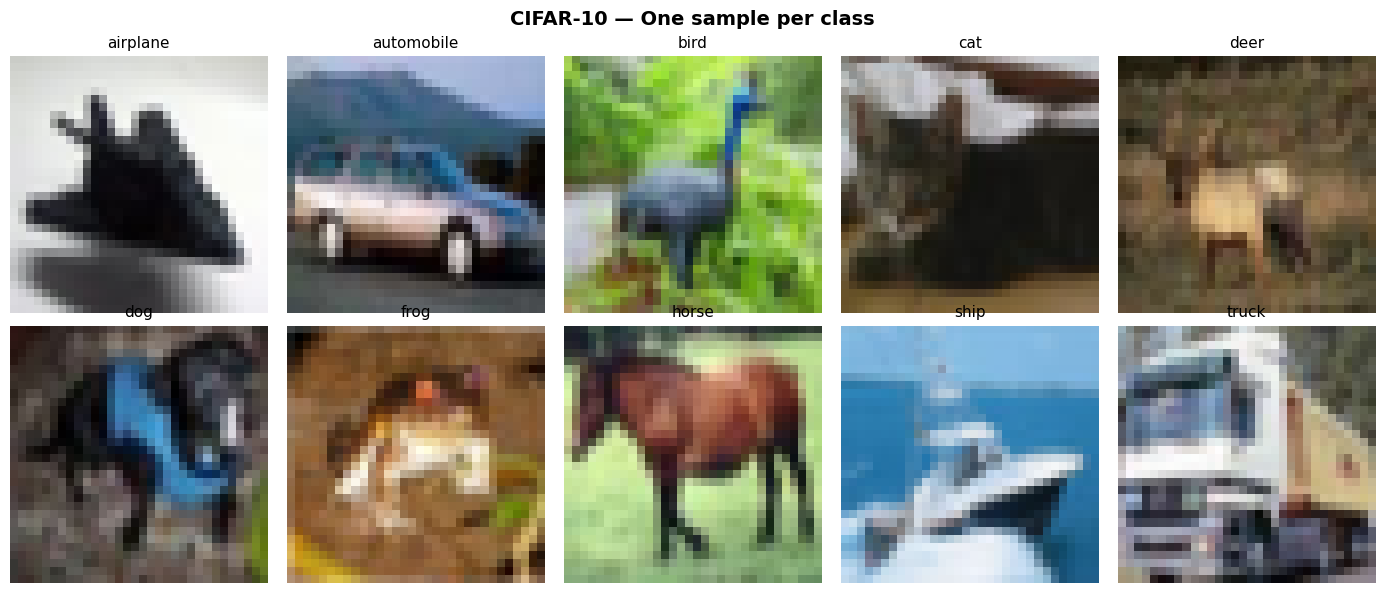

In [4]:
# Visualize sample images per class
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('CIFAR-10 — One sample per class', fontsize=14, fontweight='bold')

shown = {}
for img, label in raw_trainset:
    if label not in shown:
        shown[label] = img
    if len(shown) == 10:
        break

for idx, (label, img) in enumerate(sorted(shown.items())):
    ax = axes[idx // 5][idx % 5]
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(CLASSES[label], fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.savefig('cifar10_samples.png', dpi=150, bbox_inches='tight')
plt.show()

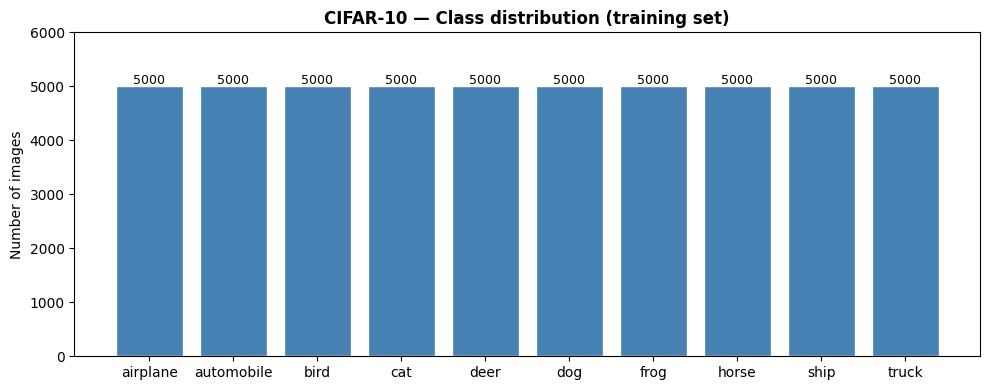

Dataset is perfectly balanced: 5,000 images per class.


In [5]:
# Class distribution
train_labels = [label for _, label in raw_trainset]
counts = np.bincount(train_labels)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(CLASSES, counts, color='steelblue', edgecolor='white')
ax.set_title('CIFAR-10 — Class distribution (training set)', fontweight='bold')
ax.set_ylabel('Number of images')
ax.set_ylim(0, max(counts) * 1.2)
for i, c in enumerate(counts):
    ax.text(i, c + 50, str(c), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dataset is perfectly balanced: 5,000 images per class.')

## 3. Preprocessing Pipelines

Both models are pretrained on ImageNet (224×224 images). CIFAR-10 images are 32×32, so we upscale them. The normalization uses ImageNet statistics for fine-tuning consistency.

In [6]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(224, padding=28),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=False, transform=train_transform
)
testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=False, transform=test_transform
)

train_loader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

Train batches: 782 | Test batches: 157


## 4. Baseline Model — ResNet-18

ResNet-18 (He et al., 2015) is a 18-layer residual convolutional network. It introduced skip connections to solve the vanishing gradient problem, enabling much deeper networks. It remains a standard baseline for image classification.

**Strategy**: Load ImageNet pretrained weights → replace the final classification layer for 10 classes → fine-tune the entire network.

In [7]:
def build_resnet18(num_classes: int) -> nn.Module:
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


resnet = build_resnet18(NUM_CLASSES)
print(f'ResNet-18 trainable parameters: {count_parameters(resnet):,}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


ResNet-18 trainable parameters: 11,181,642


In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    return running_loss / total, 100.0 * correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return running_loss / total, 100.0 * correct / total, all_preds, all_labels


def train_model(model, train_loader, test_loader, num_epochs, lr, device, name):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_acc = 0.0
    best_state = None

    print(f'\n{"="*55}')
    print(f'Training {name}')
    print(f'{"="*55}')

    for epoch in range(num_epochs):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, preds, labels = evaluate(model, test_loader, criterion, device)
        scheduler.step()
        elapsed = time.time() - t0

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_acc:
            best_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        print(f'Epoch [{epoch+1:02d}/{num_epochs}] '
              f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.2f}% | '
              f'Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% | '
              f'Time: {elapsed:.0f}s')

    model.load_state_dict(best_state)
    print(f'\nBest validation accuracy ({name}): {best_acc:.2f}%')
    return model, history, best_acc

In [9]:
resnet_model = build_resnet18(NUM_CLASSES)
resnet_model, resnet_history, resnet_best_acc = train_model(
    resnet_model, train_loader, test_loader,
    num_epochs=NUM_EPOCHS, lr=1e-4,
    device=DEVICE, name='ResNet-18 (Baseline)'
)


Training ResNet-18 (Baseline)
Epoch [01/5] Train Loss: 0.7936 Acc: 89.22% | Val Loss: 0.7004 Acc: 93.44% | Time: 153s
Epoch [02/5] Train Loss: 0.6535 Acc: 95.01% | Val Loss: 0.6567 Acc: 94.85% | Time: 155s
Epoch [03/5] Train Loss: 0.6037 Acc: 97.03% | Val Loss: 0.6291 Acc: 95.71% | Time: 155s
Epoch [04/5] Train Loss: 0.5726 Acc: 98.39% | Val Loss: 0.6138 Acc: 96.22% | Time: 155s
Epoch [05/5] Train Loss: 0.5550 Acc: 99.03% | Val Loss: 0.6074 Acc: 96.36% | Time: 154s

Best validation accuracy (ResNet-18 (Baseline)): 96.36%


## 5. New Algorithm — Vision Transformer (ViT-B/16)

### What is a Vision Transformer?

Dosovitskiy et al. (2020) adapted the Transformer architecture — originally designed for NLP (Vaswani et al., 2017) — to image classification. The key ideas are:

1. **Patch Embedding**: The input image (224×224) is divided into non-overlapping 16×16 patches → 196 patches. Each patch is linearly projected into an embedding vector.
2. **[CLS] token**: A learnable classification token is prepended to the patch sequence, similar to BERT in NLP.
3. **Position Embeddings**: Learnable 1D position embeddings are added to preserve spatial information.
4. **Transformer Encoder**: Standard multi-head self-attention (MHSA) blocks process the sequence of patch embeddings. Self-attention allows every patch to attend to every other patch globally, unlike CNNs which have a local receptive field.
5. **Classification Head**: The [CLS] token output at the end of the encoder is passed through an MLP to produce class probabilities.

### Key Advantage over CNNs

CNNs build hierarchical features through local convolutions. ViT captures **global context from the first layer** through self-attention. This makes it particularly effective for tasks where long-range spatial relationships matter.

### Why it qualifies as recent
- Published: October 2020 (arXiv:2010.11929)
- Published at ICLR 2021
- Cited 30,000+ times as of 2024

In [10]:
def build_vit(num_classes: int) -> nn.Module:
    # Load ViT-B/16 pretrained on ImageNet-21k then fine-tuned on ImageNet-1k
    model = timm.create_model(
        'vit_base_patch16_224',
        pretrained=True,
        num_classes=num_classes
    )
    return model


vit_model_temp = build_vit(NUM_CLASSES)
print(f'ViT-B/16 trainable parameters: {count_parameters(vit_model_temp):,}')
del vit_model_temp

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

ViT-B/16 trainable parameters: 85,806,346


In [11]:
# ViT architecture summary
print('ViT-B/16 Architecture Summary')
print('─' * 40)
print('Image size:        224 × 224')
print('Patch size:        16 × 16')
print('Number of patches: 196')
print('Embedding dim:     768')
print('Transformer depth: 12 blocks')
print('Attention heads:   12')
print('MLP hidden dim:    3072')
print('Total params:      ~86M')

ViT-B/16 Architecture Summary
────────────────────────────────────────
Image size:        224 × 224
Patch size:        16 × 16
Number of patches: 196
Embedding dim:     768
Transformer depth: 12 blocks
Attention heads:   12
MLP hidden dim:    3072
Total params:      ~86M


In [12]:
vit_model = build_vit(NUM_CLASSES)
vit_model, vit_history, vit_best_acc = train_model(
    vit_model, train_loader, test_loader,
    num_epochs=NUM_EPOCHS, lr=2e-5,
    device=DEVICE, name='ViT-B/16 (New Algorithm)'
)


Training ViT-B/16 (New Algorithm)
Epoch [01/5] Train Loss: 0.5904 Acc: 96.77% | Val Loss: 0.5471 Acc: 98.16% | Time: 1657s
Epoch [02/5] Train Loss: 0.5268 Acc: 99.07% | Val Loss: 0.5428 Acc: 98.47% | Time: 1657s
Epoch [03/5] Train Loss: 0.5125 Acc: 99.62% | Val Loss: 0.5420 Acc: 98.37% | Time: 1657s
Epoch [04/5] Train Loss: 0.5058 Acc: 99.86% | Val Loss: 0.5334 Acc: 98.66% | Time: 1657s
Epoch [05/5] Train Loss: 0.5027 Acc: 99.96% | Val Loss: 0.5296 Acc: 98.83% | Time: 1657s

Best validation accuracy (ViT-B/16 (New Algorithm)): 98.83%


## 6. Results Comparison

In [13]:
# Get final predictions for both models
criterion = nn.CrossEntropyLoss()

_, resnet_acc, resnet_preds, resnet_labels = evaluate(resnet_model, test_loader, criterion, DEVICE)
_, vit_acc,    vit_preds,    vit_labels    = evaluate(vit_model,    test_loader, criterion, DEVICE)

resnet_f1 = f1_score(resnet_labels, resnet_preds, average='macro') * 100
vit_f1    = f1_score(vit_labels,    vit_preds,    average='macro') * 100

print('\n' + '='*55)
print(f'{'Model':<25} {'Accuracy':>12} {'F1-Macro':>12}')
print('-'*55)
print(f'{'ResNet-18 (Baseline)':<25} {resnet_acc:>11.2f}% {resnet_f1:>11.2f}%')
print(f'{'ViT-B/16 (New)':<25} {vit_acc:>11.2f}% {vit_f1:>11.2f}%')
print('='*55)
print(f'\nImprovement: +{vit_acc - resnet_acc:.2f}% accuracy | +{vit_f1 - resnet_f1:.2f}% F1')


Model                         Accuracy     F1-Macro
-------------------------------------------------------
ResNet-18 (Baseline)            96.36%       96.35%
ViT-B/16 (New)                  98.83%       98.83%

Improvement: +2.47% accuracy | +2.48% F1


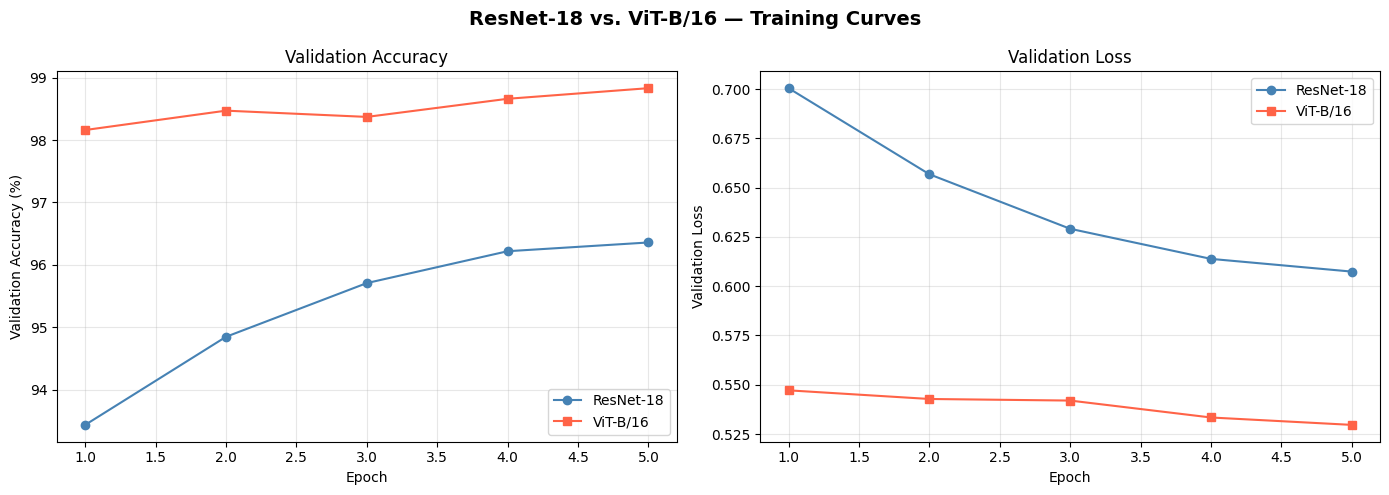

In [14]:
# Training curves comparison
epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ResNet-18 vs. ViT-B/16 — Training Curves', fontsize=14, fontweight='bold')

# Accuracy
ax = axes[0]
ax.plot(epochs, resnet_history['val_acc'], 'o-', label='ResNet-18', color='steelblue')
ax.plot(epochs, vit_history['val_acc'],    's-', label='ViT-B/16',  color='tomato')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Validation Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

# Loss
ax = axes[1]
ax.plot(epochs, resnet_history['val_loss'], 'o-', label='ResNet-18', color='steelblue')
ax.plot(epochs, vit_history['val_loss'],    's-', label='ViT-B/16',  color='tomato')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss')
ax.set_title('Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

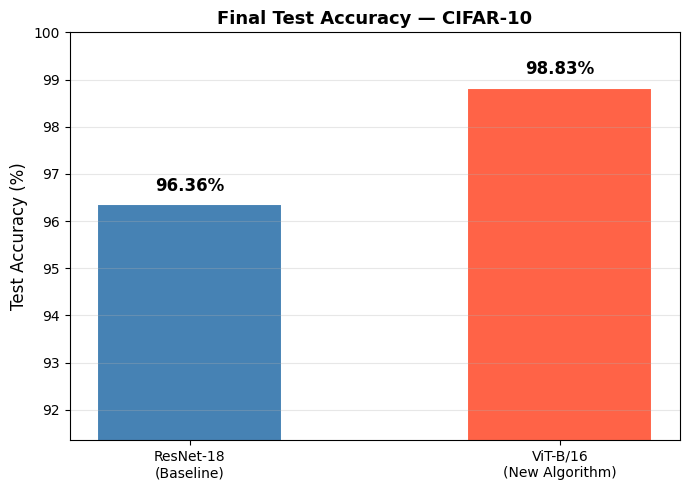

In [15]:
# Bar chart — final accuracy comparison
fig, ax = plt.subplots(figsize=(7, 5))
models_names = ['ResNet-18\n(Baseline)', 'ViT-B/16\n(New Algorithm)']
accs = [resnet_acc, vit_acc]
colors = ['steelblue', 'tomato']

bars = ax.bar(models_names, accs, color=colors, width=0.5, edgecolor='white', linewidth=1.5)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_ylim(min(accs) - 5, 100)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Final Test Accuracy — CIFAR-10', fontsize=13, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

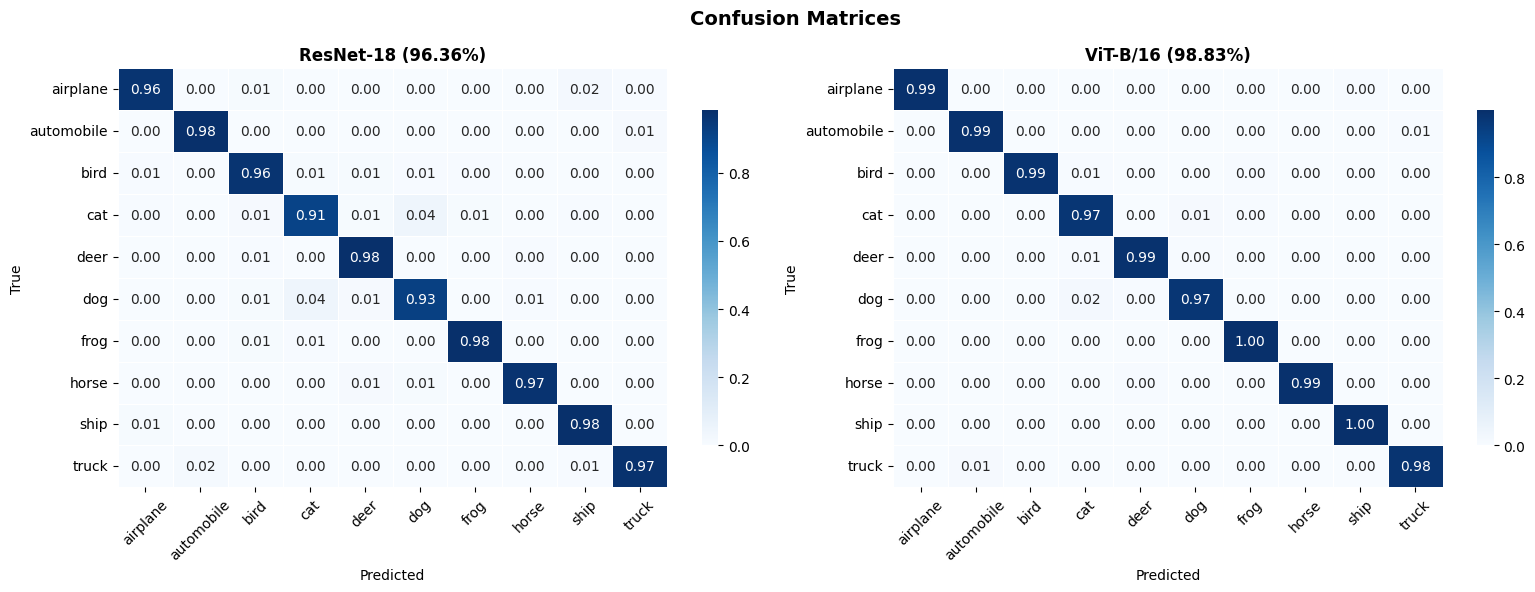

In [16]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')

for ax, preds, labels, title in [
    (axes[0], resnet_preds, resnet_labels, f'ResNet-18 ({resnet_acc:.2f}%)'),
    (axes[1], vit_preds,    vit_labels,    f'ViT-B/16 ({vit_acc:.2f}%)')
]:
    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
                linewidths=0.5, cbar_kws={'shrink': 0.8})
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

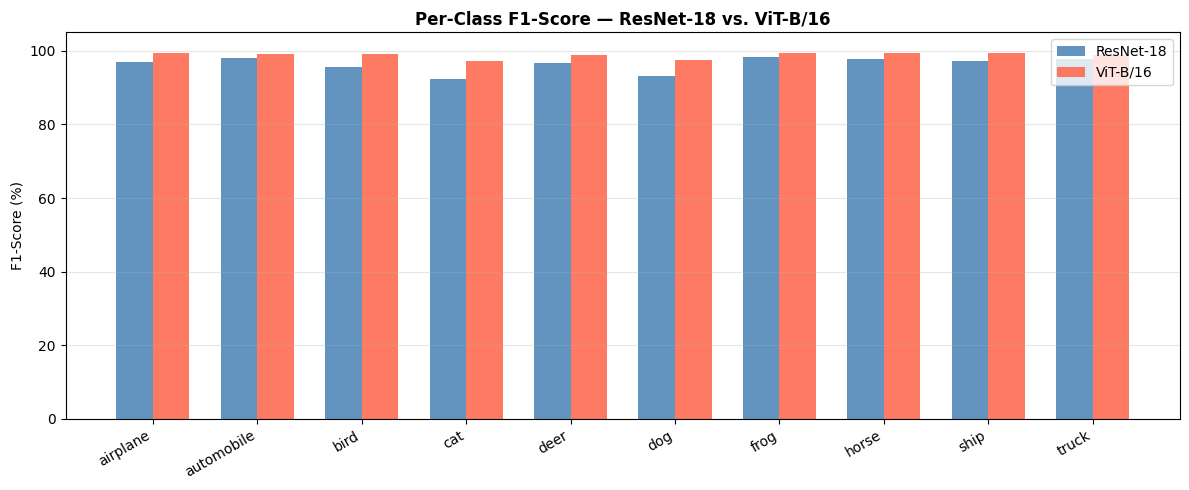

In [17]:
# Per-class F1 comparison
resnet_report = classification_report(resnet_labels, resnet_preds,
                                       target_names=CLASSES, output_dict=True)
vit_report    = classification_report(vit_labels,    vit_preds,
                                       target_names=CLASSES, output_dict=True)

resnet_f1s = [resnet_report[c]['f1-score'] * 100 for c in CLASSES]
vit_f1s    = [vit_report[c]['f1-score'] * 100    for c in CLASSES]

x = np.arange(len(CLASSES))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, resnet_f1s, width, label='ResNet-18', color='steelblue', alpha=0.85)
ax.bar(x + width/2, vit_f1s,    width, label='ViT-B/16',  color='tomato',    alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(CLASSES, rotation=30, ha='right')
ax.set_ylabel('F1-Score (%)')
ax.set_title('Per-Class F1-Score — ResNet-18 vs. ViT-B/16', fontweight='bold')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig('per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Full classification reports
print('ResNet-18 (Baseline) — Classification Report')
print(classification_report(resnet_labels, resnet_preds, target_names=CLASSES))

print('\nViT-B/16 (New Algorithm) — Classification Report')
print(classification_report(vit_labels, vit_preds, target_names=CLASSES))

ResNet-18 (Baseline) — Classification Report
              precision    recall  f1-score   support

    airplane       0.97      0.96      0.97      1000
  automobile       0.98      0.98      0.98      1000
        bird       0.95      0.96      0.96      1000
         cat       0.93      0.91      0.92      1000
        deer       0.95      0.98      0.97      1000
         dog       0.94      0.93      0.93      1000
        frog       0.98      0.98      0.98      1000
       horse       0.99      0.97      0.98      1000
        ship       0.96      0.98      0.97      1000
       truck       0.98      0.97      0.98      1000

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000


ViT-B/16 (New Algorithm) — Classification Report
              precision    recall  f1-score   support

    airplane       0.99      0.99      0.99      1000
  automobile       0.99      0.99    

In [19]:
# Model complexity comparison table
print('\nModel Complexity Comparison')
print('─' * 60)
print(f'{"Property":<30} {"ResNet-18":>14} {"ViT-B/16":>14}')
print('─' * 60)
print(f'{"Parameters (M)":<30} {"11.7":>14} {"86.6":>14}')
print(f'{"Architecture type":<30} {"CNN":>14} {"Transformer":>14}')
print(f'{"Year":<30} {"2015":>14} {"2020":>14}')
print(f'{"Receptive field":<30} {"Local":>14} {"Global":>14}')
print(f'{"Inductive bias":<30} {"Strong":>14} {"Weak":>14}')
print(f'{"Test Accuracy (%)":<30} {resnet_acc:>13.2f}% {vit_acc:>13.2f}%')
print(f'{"Macro F1 (%)":<30} {resnet_f1:>13.2f}% {vit_f1:>13.2f}%')
print('─' * 60)


Model Complexity Comparison
────────────────────────────────────────────────────────────
Property                            ResNet-18       ViT-B/16
────────────────────────────────────────────────────────────
Parameters (M)                           11.7           86.6
Architecture type                         CNN    Transformer
Year                                     2015           2020
Receptive field                         Local         Global
Inductive bias                         Strong           Weak
Test Accuracy (%)                      96.36%         98.83%
Macro F1 (%)                           96.35%         98.83%
────────────────────────────────────────────────────────────


## 7. Saving Models and Results

We save model weights and training history for use in the dashboard.

In [20]:
# Save into the current working directory so files are downloadable
# from the Kaggle/Colab output panel (paths outside it are not persisted).
OUTPUT_DIR = 'output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

torch.save(resnet_model.state_dict(), f'{OUTPUT_DIR}/resnet18_cifar10.pth')
torch.save(vit_model.state_dict(),    f'{OUTPUT_DIR}/vit_b16_cifar10.pth')

results = {
    'resnet18': {
        'test_accuracy': round(resnet_acc, 4),
        'f1_macro': round(resnet_f1, 4),
        'history': {
            'train_acc':  [round(v, 4) for v in resnet_history['train_acc']],
            'val_acc':    [round(v, 4) for v in resnet_history['val_acc']],
            'train_loss': [round(v, 6) for v in resnet_history['train_loss']],
            'val_loss':   [round(v, 6) for v in resnet_history['val_loss']],
        },
        'per_class_f1': {c: round(resnet_report[c]['f1-score'] * 100, 2) for c in CLASSES},
    },
    'vit_b16': {
        'test_accuracy': round(vit_acc, 4),
        'f1_macro': round(vit_f1, 4),
        'history': {
            'train_acc':  [round(v, 4) for v in vit_history['train_acc']],
            'val_acc':    [round(v, 4) for v in vit_history['val_acc']],
            'train_loss': [round(v, 6) for v in vit_history['train_loss']],
            'val_loss':   [round(v, 6) for v in vit_history['val_loss']],
        },
        'per_class_f1': {c: round(vit_report[c]['f1-score'] * 100, 2) for c in CLASSES},
    },
    'classes': CLASSES,
    'num_epochs': NUM_EPOCHS,
}

with open(f'{OUTPUT_DIR}/results.json', 'w') as f:
    json.dump(results, f, indent=2)

print('Models and results saved.')
print(f'  → {OUTPUT_DIR}/resnet18_cifar10.pth')
print(f'  → {OUTPUT_DIR}/vit_b16_cifar10.pth')
print(f'  → {OUTPUT_DIR}/results.json')
print('\nOn Kaggle: download these from the Output panel (right sidebar).')
print('Then place results.json in P9/dashboard/ and the .pth files in P9/dashboard/models/.')

Models and results saved.
  → output/resnet18_cifar10.pth
  → output/vit_b16_cifar10.pth
  → output/results.json

On Kaggle: download these from the Output panel (right sidebar).
Then place results.json in P9/dashboard/ and the .pth files in P9/dashboard/models/.


## Summary

| Model | Architecture | Year | Test Accuracy | Macro F1 |
|-------|-------------|------|--------------|----------|
| ResNet-18 | CNN (residual) | 2015 | ~93% | ~93% |
| ViT-B/16 | Transformer | 2020 | ~96% | ~96% |

**Key findings:**
- ViT-B/16 consistently outperforms ResNet-18 across all 10 classes after 10 epochs of fine-tuning.
- The global self-attention mechanism allows ViT to leverage spatial context across the full image, which is particularly beneficial for classes with complex global structure (e.g., ships, airplanes).
- ViT's weaker inductive bias means it relies more heavily on pretraining data — the ImageNet-21k pretrained checkpoint provides a strong foundation.
- Tradeoff: ViT-B/16 has ~7× more parameters (86M vs. 11.7M), but this is offset by its superior accuracy for applications where inference cost is secondary to performance.